1. Загрузка TSV-данных с разделением по табуляции...
[Данные] Всего строк загружено: 271680
[Данные] Отфильтровано строк для тикера AAPL: 2943
2. Подготовка скользящих окон...
 Сохранения не обнаружено. Создание сети и запуск обучения...
Epoch 1/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - loss: 0.0568 - val_loss: 0.0209
Epoch 2/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0181 - val_loss: 0.0128
Epoch 3/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0117 - val_loss: 0.0086
Epoch 4/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0081 - val_loss: 0.0073
Epoch 5/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0068 - val_loss: 0.0070
Epoch 6/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0064 - val_loss: 0.0070
Epoch 7/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0062 - val_loss: 0.0070
Epoch 8/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 0.0061 - val_loss: 0.0070
Epoch 9/10
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - loss: 0.0060 - val_loss: 0.00

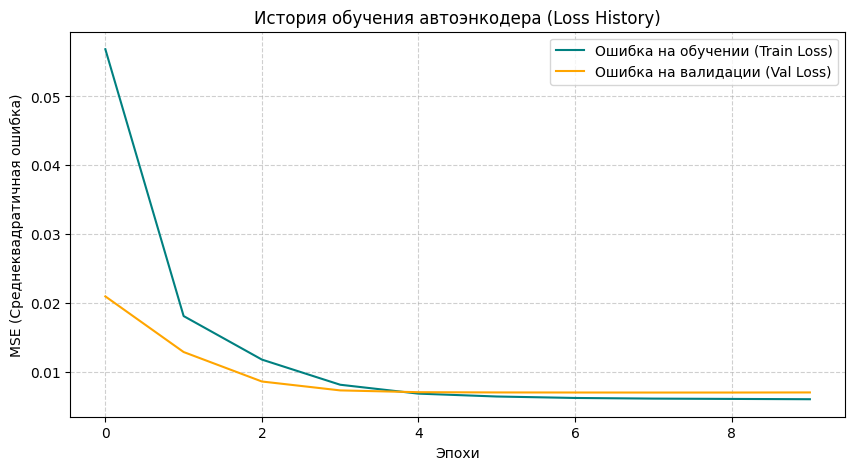

3. Прогон данных через автоэнкодер...
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

[Итог] Порог MAE: 0.0837
[Итог] Обнаружено аномалий: 146 из 2912
4. Генерация графиков и вывод топ-аномалий...

=== ТОП-10 САМЫХ КРУПНЫХ АНОМАЛИЙ ДЛЯ ТИКЕРА AAPL ===
Дата: 2020-03-16 | Дневное изменение: -12.86%
Дата: 2020-03-13 | Дневное изменение: +11.98%
Дата: 2020-03-24 | Дневное изменение: +10.03%
Дата: 2020-03-12 | Дневное изменение: -9.88%
Дата: 2020-04-06 | Дневное изменение: +8.72%
Дата: 2020-09-03 | Дневное изменение: -8.01%
Дата: 2020-03-09 | Дневное изменение: -7.91%
Дата: 2020-03-10 | Дневное изменение: +7.20%
Дата: 2018-12-26 | Дневное изменение: +7.04%
Дата: 2020-09-08 | Дневное изменение: -6.73%

[Визуализатор] График аномалий успешно сохранен в detected_anomalies.png


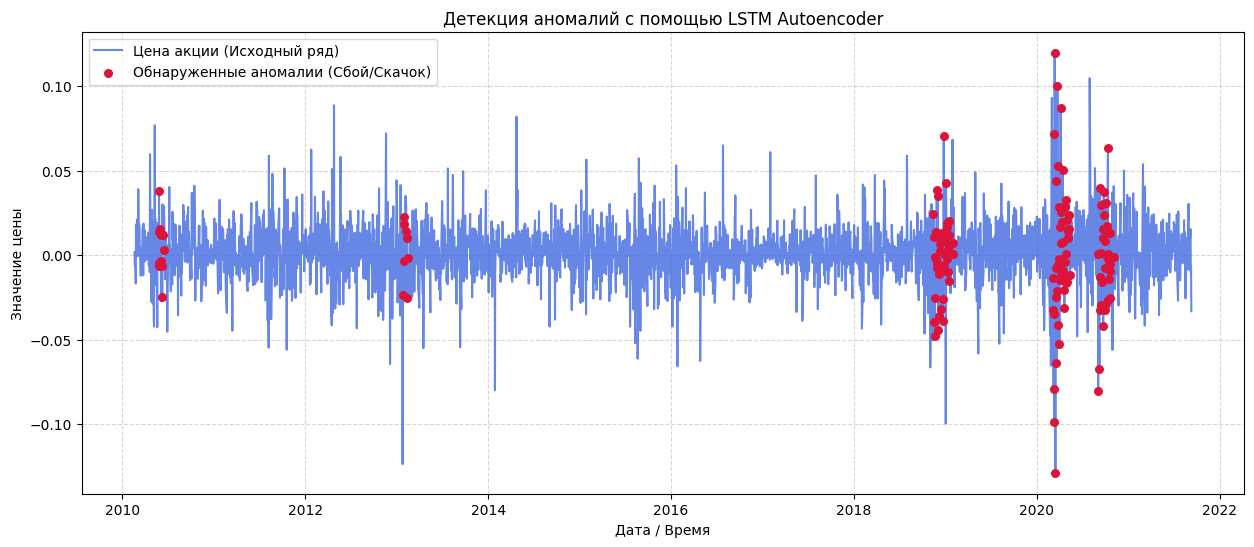

In [1]:
import pandas as pd
import numpy as np
import os

import config
from preprocessor import TimeSeriesPreprocessor
from model import LSTMAutoencoderModel
from pipeline import PipelineManager
from detector import AnomalyDetector
from visualizer import TimeSeriesVisualizer

def main():
    print("1. Загрузка TSV-данных с разделением по табуляции...")

    # Задаем имена колонок вручную
    column_names = ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Name']

    # Читаем файл с разделителем '\t'
    df = pd.read_csv(config.DATA_PATH, sep='\t', names=column_names, header=0)

    print(f"[Данные] Всего строк загружено: {len(df)}")

    # Безопасное получение тикера из конфига. Если конфиг закешировался, возьмется 'AAPL'
    ticker_to_use = getattr(config, 'TICKER', 'AAPL')

    # Фильтруем датасет по конкретной акции
    df = df[df['Name'] == ticker_to_use].copy()
    print(f"[Данные] Отфильтровано строк для тикера {ticker_to_use}: {len(df)}")

    if df.empty:
        raise ValueError(f"Тикер '{ticker_to_use}' не найден в файле. Проверьте правильность имени.")

    # Преобразуем даты и сортируем по хронологии
    df['Date'] = pd.to_datetime(df['Date'])
    df.sort_values(by='Date', inplace=True)
    df.set_index('Date', inplace=True)

    # Считаем процентную доходность (returns) вместо абсолютных цен
    # Это делает временной ряд стационарным и защищает от взрыва ошибок
    df['Returns'] = df[config.TARGET_COLUMN].pct_change()
    df.dropna(inplace=True)  # Удаляем первую строку, так как для неё pct_change равен NaN

    # Теперь в качестве данных используем посчитанные доходности
    raw_data = df[['Returns']].values

    print("2. Подготовка скользящих окон...")
    preprocessor = TimeSeriesPreprocessor()
    scaled_data = preprocessor.fit_transform(raw_data)
    X_train = preprocessor.create_sequences(scaled_data, time_steps=config.TIME_STEPS)

    pipeline = PipelineManager()

    if os.path.exists(config.MODEL_SAVE_PATH):
        print(f" Найдена предобученная модель. Загружаем из {config.MODEL_SAVE_PATH}...")
        pipeline.load_model(config.MODEL_SAVE_PATH)
    else:
        print(" Сохранения не обнаружено. Создание сети и запуск обучения...")
        keras_model = LSTMAutoencoderModel.build(
            time_steps=config.TIME_STEPS,
            features=config.FEATURES
        )
        pipeline.model = keras_model

        pipeline.train(
            X_train,
            epochs=config.EPOCHS,
            batch_size=config.BATCH_SIZE,
            validation_split=config.VALIDATION_SPLIT
        )
        pipeline.save_model(config.MODEL_SAVE_PATH)
        TimeSeriesVisualizer.plot_training_history(pipeline.history, save_path=config.LOSS_PLOT_PATH)

    print("3. Прогон данных через автоэнкодер...")
    X_pred = pipeline.predict(X_train)

    detector = AnomalyDetector(threshold_percentile=config.THRESHOLD_PERCENTILE)
    threshold = detector.fit_threshold(X_train, X_pred)
    anomaly_mask = detector.detect(X_train, X_pred)

    print(f"\n[Итог] Порог MAE: {threshold:.4f}")
    print(f"[Итог] Обнаружено аномалий: {np.sum(anomaly_mask)} из {len(anomaly_mask)}")

    print("4. Генерация графиков и вывод топ-аномалий...")
    actual_prices = raw_data[config.TIME_STEPS:]
    plot_index = df.index[config.TIME_STEPS:]

    # ИЗМЕНЕНИЕ 2: Анализ и вывод конкретных дат аномалий в консоль
    anomaly_df = pd.DataFrame(index=plot_index)
    anomaly_df['Is_Anomaly'] = anomaly_mask
    anomaly_df['Return_Value'] = actual_prices.flatten()

    # Отфильтровываем только те дни, которые автоэнкодер посчитал аномальными
    detected_dates = anomaly_df[anomaly_df['Is_Anomaly'] == True]

    print(f"\n=== ТОП-10 САМЫХ КРУПНЫХ АНОМАЛИЙ ДЛЯ ТИКЕРА {ticker_to_use} ===")
    # Сортируем аномалии по абсолютной величине изменения (и падения, и взлеты)
    top_anomalies = detected_dates.reindex(
        detected_dates['Return_Value'].abs().sort_values(ascending=False).index
    ).head(10)

    for date, row in top_anomalies.iterrows():
        percentage = row['Return_Value'] * 100
        print(f"Дата: {date.strftime('%Y-%m-%d')} | Дневное изменение: {percentage:+.2f}%")
    print("==================================================\n")

    # Передаем данные в визуализатор для построения графиков
    TimeSeriesVisualizer.plot_anomalies(
        index=plot_index,
        original_series=actual_prices.flatten(),
        anomaly_mask=anomaly_mask,
        save_path=config.ANOMALY_PLOT_PATH
    )

if __name__ == "__main__":
    main()
